# Step 1: Data preparation


In [1]:
import os
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular

import preprocess

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure fully deterministic behavior in PyTorch backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

#change to a binary label
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

print(f"[*] Cleaned Feature matrix shape: {X.shape}")
print(f"[*] Target distribution: Benign (0) = {np.sum(y == 0)}, Attack (1) = {np.sum(y == 1)}")


[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\preprocess.py:12: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin-1')


[-] Dropped identifier columns: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
[!] Purged 288737 malformed rows containing Infinity or empty cells.
[*] Cleaned Feature matrix shape: (170231, 78)
[*] Target distribution: Benign (0) = 168051, Attack (1) = 2180


In [4]:
# Step A: Split off 30% of the data into a temporary block, stratifying to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step B: Split the temporary block evenly to yield a 15% Validation set and a 15% Test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("==================== DATA SPLIT SUMMARY ====================")
print(f"Training Set (70%):   X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation Set (15%): X = {X_val.shape}, y = {y_val.shape}")
print(f"Test Set (15%):       X = {X_test.shape}, y = {y_test.shape}")

==================== DATA SPLIT SUMMARY ====================
Training Set (70%):   X = (119161, 78), y = (119161,)
Validation Set (15%): X = (25535, 78), y = (25535,)
Test Set (15%):       X = (25535, 78), y = (25535,)


In [5]:
# 1. Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 2. Correlated Feature Groups (Supervisor point 15 & 16)
corr_matrix = X_train_scaled.corr(method="spearman")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"[*] Features identified for potential removal (>0.90 correlation): {len(to_drop)}")

[*] Features identified for potential removal (>0.90 correlation): 39


In [6]:
# Initialize SMOTE-Tomek with a fixed seed for strict reproducibility
smote_tomek = SMOTETomek(random_state=42)

# Resample ONLY the training set
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("================= RESAMPLING SUMMARY =================")
print(f"Original Training Class Ratios: 0 = {np.sum(y_train == 0)}, 1 = {np.sum(y_train == 1)}")
print(f"Resampled Training Data Shape:  X = {X_train_resampled.shape}, y = {y_train_resampled.shape}")
print(f"Resampled Training Class Ratios: 0 = {np.sum(y_train_resampled == 0)}, 1 = {np.sum(y_train_resampled == 1)}")

================= RESAMPLING SUMMARY =================
Original Training Class Ratios: 0 = 117635, 1 = 1526
Resampled Training Data Shape:  X = (235254, 78), y = (235254,)
Resampled Training Class Ratios: 0 = 117627, 1 = 117627


# Step 2: Model development

In [7]:
print("[*] Initializing XGBoost Classifier...")

# Initialize XGBoost with strict reproducibility parameters
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

# Fit model with early stopping monitored against the validation split
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"[*] XGBoost training complete.")
print(f"    -> Best Iteration: {xgb_model.best_iteration}")

[*] Initializing XGBoost Classifier...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [10:26:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[*] XGBoost training complete.
    -> Best Iteration: 398


In [8]:
class RobustNetworkSecurityDNN(nn.Module):
    def __init__(self, input_dim):
        super(RobustNetworkSecurityDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features_count = X_train_resampled.shape[1]

# Instantiate model architecture
model_dnn = RobustNetworkSecurityDNN(input_dim=input_features_count).to(device)
print(f"[*] PyTorch Network mapped successfully onto target hardware device: {device.type.upper()}")

[*] PyTorch Network mapped successfully onto target hardware device: CPU


In [9]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer equations and standard binary loss scoring
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

print("[*] Initiating DNN optimization loop...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Zero Leakage Check)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = model_dnn.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Overfitting threshold neutralized.")
        break

# Roll back parameter matrix states to the optimal captured validation validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_3472\1641040915.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)


[*] Initiating DNN optimization loop...
[*] Early stopping triggered at Epoch 21. Overfitting threshold neutralized.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


In [10]:
# Helper function to generate clean inference probability matrices from our DNN
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Step A: Collect raw feature inference array probabilities from validation subsets
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Step B: Declare target tuning thresholds range
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    # Evaluate XGBoost arrays
    xgb_preds = (xgb_val_probs >= t).astype(int)
    xgb_f1 = f1_score(y_val, xgb_preds, zero_division=0)
    if xgb_f1 > best_xgb_f1:
        best_xgb_f1 = xgb_f1
        best_xgb_threshold = t
        
    # Evaluate DNN arrays
    dnn_preds = (dnn_val_probs >= t).astype(int)
    dnn_f1 = f1_score(y_val, dnn_preds, zero_division=0)
    if dnn_f1 > best_dnn_f1:
        best_dnn_f1 = dnn_f1
        best_dnn_threshold = t
        
    print(f"Threshold: {t:.2f} | XGB F1: {xgb_f1:.4f} | DNN F1: {dnn_f1:.4f}")

print("\n[*] Calibrated Decision Parameter Options Frozen:")
print(f"    -> Selected Frozen XGBoost Threshold: {best_xgb_threshold:.2f} (Val F1: {best_xgb_f1:.4f})")
print(f"    -> Selected Frozen DNN Threshold:     {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | XGB F1: 0.9954 | DNN F1: 0.5496
Threshold: 0.55 | XGB F1: 0.9954 | DNN F1: 0.5595
Threshold: 0.60 | XGB F1: 0.9954 | DNN F1: 0.5692
Threshold: 0.65 | XGB F1: 0.9954 | DNN F1: 0.5834
Threshold: 0.70 | XGB F1: 0.9954 | DNN F1: 0.6044
Threshold: 0.75 | XGB F1: 0.9970 | DNN F1: 0.6211
Threshold: 0.80 | XGB F1: 0.9970 | DNN F1: 0.6349
Threshold: 0.85 | XGB F1: 0.9969 | DNN F1: 0.8587
Threshold: 0.90 | XGB F1: 0.9969 | DNN F1: 0.8575
Threshold: 0.95 | XGB F1: 0.9985 | DNN F1: 0.8584

[*] Calibrated Decision Parameter Options Frozen:
    -> Selected Frozen XGBoost Threshold: 0.95 (Val F1: 0.9985)
    -> Selected Frozen DNN Threshold:     0.85 (Val F1: 0.8587)


In [11]:
def calculate_advanced_metrics(y_true, probs, threshold, fn_cost=10, fp_cost=1):
    preds = (probs >= threshold).astype(int)
    
    # Core scikit-learn operations
    balanced_acc = balanced_accuracy_score(y_true, preds)
    mcc = matthews_corrcoef(y_true, preds)
    
    # Calculate Precision-Recall Area Under Curve (PR-AUC)
    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)
    
    # Extract confusion elements to calculate operational cost
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    
    total_operational_cost = (fn * fn_cost) + (fp * fp_cost)
    
    return {
        "Balanced Accuracy": balanced_acc,
        "MCC": mcc,
        "PR-AUC": pr_auc,
        "Operational Cost": total_operational_cost,
        "False Negatives": fn,
        "False Positives": fp
    }

# Evaluate both models on validation data using the selected threshold
print("=================== ADVANCED OPERATIONAL METRICS ===================")
xgb_adv = calculate_advanced_metrics(y_val, xgb_val_probs, best_xgb_threshold)
dnn_adv = calculate_advanced_metrics(y_val, dnn_val_probs, best_dnn_threshold)

for metric in ["Balanced Accuracy", "MCC", "PR-AUC", "Operational Cost", "False Negatives", "False Positives"]:
    print(f"{metric:<20} | XGBoost: {xgb_adv[metric]:.4f} | DNN: {dnn_adv[metric]:.4f}")
print("====================================================================")

=================== ADVANCED OPERATIONAL METRICS ===================
Balanced Accuracy    | XGBoost: 0.9985 | DNN: 0.9858
MCC                  | XGBoost: 0.9984 | DNN: 0.8630
PR-AUC               | XGBoost: 1.0000 | DNN: 0.9636
Operational Cost     | XGBoost: 10.0000 | DNN: 177.0000
False Negatives      | XGBoost: 1.0000 | DNN: 8.0000
False Positives      | XGBoost: 0.0000 | DNN: 97.0000


In [12]:
def expected_calibration_error(y_true, probs, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')
    ece = 0.0
    n_samples = len(y_true)
    
    # Bin sorting simulation loop
    bin_edges = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        bin_idx = (probs > bin_edges[i]) & (probs <= bin_edges[i+1])
        bin_weight = np.sum(bin_idx) / n_samples
        if bin_weight > 0:
            bin_actual = np.mean(y_true[bin_idx])
            bin_predicted = np.mean(probs[bin_idx])
            ece += bin_weight * np.abs(bin_actual - bin_predicted)
    return ece

# Compute calibration diagnostics on the validation split
xgb_brier = brier_score_loss(y_val, xgb_val_probs)
dnn_brier = brier_score_loss(y_val, dnn_val_probs)

xgb_ece = expected_calibration_error(y_val, xgb_val_probs)
dnn_ece = expected_calibration_error(y_val, dnn_val_probs)

print("==================== PROBABILITY CALIBRATION ====================")
print(f"Brier Score Loss | XGBoost: {xgb_brier:.5f} | DNN: {dnn_brier:.5f}")
print(f"ECE (Uniform)    | XGBoost: {xgb_ece:.5f}  | DNN: {dnn_ece:.5f}")
print("=================================================================")

==================== PROBABILITY CALIBRATION ====================
Brier Score Loss | XGBoost: 0.00009 | DNN: 0.01432
ECE (Uniform)    | XGBoost: 0.00018  | DNN: 0.01837


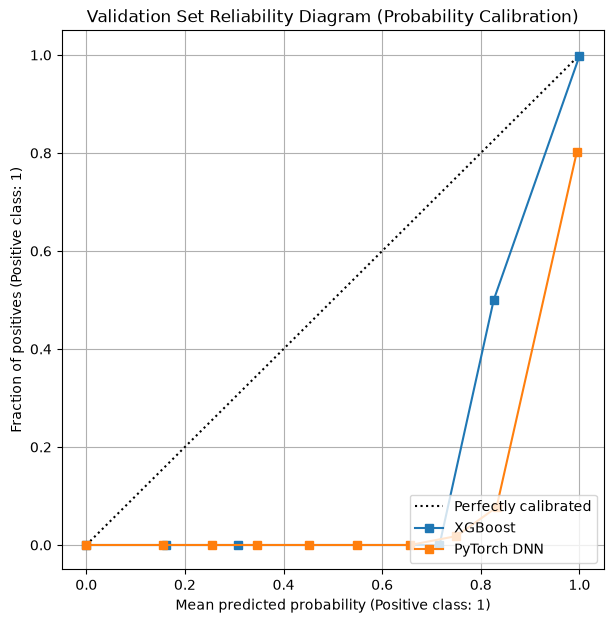

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(y_val, xgb_val_probs, n_bins=10, name="XGBoost", ax=ax)
CalibrationDisplay.from_predictions(y_val, dnn_val_probs, n_bins=10, name="PyTorch DNN", ax=ax)

ax.set_title("Validation Set Reliability Diagram (Probability Calibration)")
plt.grid(True)
plt.show()

In [14]:
# Step A: Extract test predictions using frozen configurations
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
dnn_test_probs = get_dnn_probabilities(X_test_scaled)

xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Step B: Print formal validation summaries for your thesis report
print("=================== FINAL FROZEN XGBOOST REPORT ===================")
print(f"Applied Decision Threshold: {best_xgb_threshold:.2f}")
print(confusion_matrix(y_test, xgb_test_preds))
print(classification_report(y_test, xgb_test_preds, digits=4))

print("\n==================== FINAL FROZEN DNN REPORT ====================")
print(f"Applied Decision Threshold: {best_dnn_threshold:.2f}")
print(confusion_matrix(y_test, dnn_test_preds))
print(classification_report(y_test, dnn_test_preds, digits=4))

=================== FINAL FROZEN XGBOOST REPORT ===================
Applied Decision Threshold: 0.95
[[25207     1]
 [    4   323]]
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     25208
           1     0.9969    0.9878    0.9923       327

    accuracy                         0.9998     25535
   macro avg     0.9984    0.9939    0.9961     25535
weighted avg     0.9998    0.9998    0.9998     25535


==================== FINAL FROZEN DNN REPORT ====================
Applied Decision Threshold: 0.85
[[25111    97]
 [   18   309]]
              precision    recall  f1-score   support

           0     0.9993    0.9962    0.9977     25208
           1     0.7611    0.9450    0.8431       327

    accuracy                         0.9955     25535
   macro avg     0.8802    0.9706    0.9204     25535
weighted avg     0.9962    0.9955    0.9957     25535



In [15]:
# Standardized probability wrappers for the explainers
def xgb_predict_proba_wrapper(x_numpy):
    # Map numpy matrix rows directly back to pandas format to preserve column naming indices natively
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    return xgb_model.predict_proba(df_temp)

def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Step 3: baseline explanation setup

In [16]:
# Map feature list and order cleanly from the step 1 variables
feature_list = X_train_scaled.columns.tolist()
x_train_unresampled_numpy = X_train_scaled.values

# Initialize LIME Tabular Explainer with fixed seed for absolute reproducibility
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train_unresampled_numpy,
    feature_names=feature_list,
    class_names=["Benign", "Web Attack"],
    mode="classification",
    kernel_width=None, # Standard baseline width (to be evaluated later)
    random_state=42
)

In [17]:
# Clear, unresampled background sample for both KernelExplainers
shap_background_baseline = shap.sample(X_train_scaled, 100, random_state=42)

shap_explainer_xgb = shap.KernelExplainer(
    model=xgb_predict_proba_wrapper,
    data=shap_background_baseline
)

shap_explainer_dnn = shap.KernelExplainer(
    model=dnn_predict_proba_wrapper,
    data=shap_background_baseline
)


In [18]:
def extract_aligned_lime_attributions(instance, predict_fn, num_features):
    """
    Generates local linear surrogate attributions and extracts weights directly 
    via feature indices to completely prevent string interval truncation errors.
    """
    # Force explanation extraction explicitly for Class 1 (Web Attack)
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=predict_fn,
        labels=(1,),
        num_features=num_features
    )
    
    # Isolate the underlying index-to-weight mapping array for Class 1
    raw_local_exp = exp.local_exp[1]
    index_to_weight = {feature_idx: weight for feature_idx, weight in raw_local_exp}
    
    # Reconstruct the uniform vector following native column positioning
    total_features = x_train_unresampled_numpy.shape[1]
    lime_vector = np.zeros(total_features)
    for idx in range(total_features):
        lime_vector[idx] = index_to_weight.get(idx, 0.0)
        
    # Capture R-squared local surrogate training fidelity
    fidelity_score = exp.score
    
    return lime_vector, fidelity_score


def extract_aligned_shap_attributions(instance, explainer):
    """
    Extracts local SHAP attribution vectors aligned explicitly to Class 1 (Web Attack)
    natively via unified KernelExplainer multi-output tracking.
    """
    # Unified execution path: sampling permutations with a baseline budget of 100
    raw_values = explainer.shap_values(instance, nsamples=100)
    
    # Handle structural differences across different SHAP / NumPy versions dynamically
    if isinstance(raw_values, list):
        # Format A: List of length 2 -> Index 1 isolates Class 1 (Attack)
        shap_vector = raw_values[1]
    elif isinstance(raw_values, np.ndarray):
        # Format B: NumPy Array -> Inspect dimensions to pull Class 1
        if len(raw_values.shape) == 2:
            if raw_values.shape[1] == 2:   # Shape is (78, 2) -> Column 1 is Class 1
                shap_vector = raw_values[:, 1]
            elif raw_values.shape[0] == 2: # Shape is (2, 78) -> Row 1 is Class 1
                shap_vector = raw_values[1, :]
            else:
                shap_vector = raw_values
        else:
            shap_vector = raw_values
    else:
        shap_vector = raw_values
        
    return np.array(shap_vector).flatten()


In [19]:
# Isolate a single sample instance from our validation split for the test run
sample_idx = 0
verification_sample = X_val_scaled.iloc[sample_idx].values

print("=================== SHAPE & ALIGNMENT CHECK ===================")

# 1. Run XGBoost baseline extractions
lime_xgb_w, xgb_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=xgb_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_xgb_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_xgb
)

# 2. Run DNN baseline extractions
lime_dnn_w, dnn_fid = extract_aligned_lime_attributions(
    instance=verification_sample,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=X_val_scaled.shape[1]
)
shap_dnn_w = extract_aligned_shap_attributions(
    instance=verification_sample,
    explainer=shap_explainer_dnn
)

print(f"XGBoost Pipeline -> LIME Matrix Shape: {lime_xgb_w.shape} | Fidelity R2: {xgb_fid:.4f}")
print(f"XGBoost Pipeline -> SHAP Matrix Shape: {shap_xgb_w.shape}")
print(f"DNN Pipeline     -> LIME Matrix Shape: {lime_dnn_w.shape} | Fidelity R2: {dnn_fid:.4f}")
print(f"DNN Pipeline     -> SHAP Matrix Shape: {shap_dnn_w.shape}")

# Hard validation assertions to confirm mathematical alignment before loop matrix calculation
assert lime_xgb_w.shape == shap_xgb_w.shape, "Error: XGBoost attribution dimensions mismatched!"
assert lime_dnn_w.shape == shap_dnn_w.shape, "Error: DNN attribution dimensions mismatched!"
print("\n[+] Verification successful: Dimensions are perfectly aligned across architectures.")
print("===============================================================")

=================== SHAPE & ALIGNMENT CHECK ===================
XGBoost Pipeline -> LIME Matrix Shape: (78,) | Fidelity R2: 0.0138
XGBoost Pipeline -> SHAP Matrix Shape: (78,)
DNN Pipeline     -> LIME Matrix Shape: (78,) | Fidelity R2: 0.0158
DNN Pipeline     -> SHAP Matrix Shape: (78,)

[+] Verification successful: Dimensions are perfectly aligned across architectures.


In [20]:
background_sizes = [50, 100, 200]

print("================== SHAP BACKGROUND SENSITIVITY AUDIT ==================")
for size in background_sizes:
    # 1. Sample an authentic background dataset from unresampled training data
    temp_background = shap.sample(X_train_scaled, size, random_state=42)
    
    # 2. Initialize a temporary model-agnostic KernelExplainer for XGBoost
    temp_explainer_xgb = shap.KernelExplainer(
        model=xgb_predict_proba_wrapper,
        data=temp_background
    )
    
    # 3. Extract class-aligned feature attributions for the verification sample
    sampled_shap_values = extract_aligned_shap_attributions(
        instance=verification_sample,
        explainer=temp_explainer_xgb
    )
    
    # 4. Compute the vector magnitude (L2 norm) to track absolute scaling shifts
    vector_magnitude = np.linalg.norm(sampled_shap_values)
    
    print(f"Background Size: {size:3d} | Unified SHAP Vector L2 Norm: {vector_magnitude:.6f}")
print("=======================================================================")

================== SHAP BACKGROUND SENSITIVITY AUDIT ==================
Background Size:  50 | Unified SHAP Vector L2 Norm: 0.019006
Background Size: 100 | Unified SHAP Vector L2 Norm: 0.007611


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Background Size: 200 | Unified SHAP Vector L2 Norm: 0.008599


# Step 4 Agreement Analysis

In [21]:
# =====================================================================
# STEP 4.1: DETERMINISTIC STRATIFIED & BORDERLINE COHORT SAMPLING
# =====================================================================

# Initialize the robust random number generator as planned
rng = np.random.default_rng(42)
target_sample_size = 50

# Identify prediction quadrants using your frozen test predictions from Cell 15
tp_all_idx = np.where((y_test == 1) & (xgb_test_preds == 1))[0]
tn_all_idx = np.where((y_test == 0) & (xgb_test_preds == 0))[0]
fp_all_idx = np.where((y_test == 0) & (xgb_test_preds == 1))[0]
fn_all_idx = np.where((y_test == 1) & (xgb_test_preds == 0))[0]

# Sample strictly up to 50 rows per standard quadrant
sampled_tp = rng.choice(tp_all_idx, min(target_sample_size, len(tp_all_idx)), replace=False) if len(tp_all_idx) > 0 else np.array([])
sampled_tn = rng.choice(tn_all_idx, min(target_sample_size, len(tn_all_idx)), replace=False) if len(tn_all_idx) > 0 else np.array([])
sampled_fp = rng.choice(fp_all_idx, min(target_sample_size, len(fp_all_idx)), replace=False) if len(fp_all_idx) > 0 else np.array([])
sampled_fn = rng.choice(fn_all_idx, min(target_sample_size, len(fn_all_idx)), replace=False) if len(fn_all_idx) > 0 else np.array([])

# Create a master set of all standard sampled indices to avoid duplicate reuse in borderline category
standard_sampled_indices = set(np.concatenate([sampled_tp, sampled_tn, sampled_fp, sampled_fn]))

# Calculate the distance of every test record to your frozen XGBoost threshold
distances_to_threshold = np.abs(xgb_test_probs - best_xgb_threshold)

# Sort indices from closest to farthest from the decision boundary
sorted_by_closeness = np.argsort(distances_to_threshold)

# Filter out rows already selected in standard categories to ensure unique insights
borderline_idx = [idx for idx in sorted_by_closeness if idx not in standard_sampled_indices]
sampled_borderline = np.array(borderline_idx[:target_sample_size])

# Combine everything into our clean stratified target execution dictionary
cohort_samples = {
    'True Positive': sampled_tp,
    'True Negative': sampled_tn,
    'False Positive': sampled_fp,
    'False Negative': sampled_fn,
    'Borderline Case': sampled_borderline
}

print("=====================================================================")
print("             ADVANCED STRATIFIED STUDY COHORTS DISCOVERED            ")
print("=====================================================================")
for cohort, indices in cohort_samples.items():
    print(f" -> {cohort:18s} | Selected Samples: {len(indices)}")
print("=====================================================================")

             ADVANCED STRATIFIED STUDY COHORTS DISCOVERED            
 -> True Positive      | Selected Samples: 50
 -> True Negative      | Selected Samples: 50
 -> False Positive     | Selected Samples: 1
 -> False Negative     | Selected Samples: 4
 -> Borderline Case    | Selected Samples: 50


In [22]:
# =====================================================================
# STEP 4.2: SUITE OF EXPERIMENTAL METRICS & RANDOM BASELINE SIMULATION
# =====================================================================

agreement_records = []
num_features_total = X_test_scaled.shape[1]

# Pre-compute the 10,000-iteration random baseline values once to save overhead time
print("[*] Running 10,000-iteration Monte Carlo random reference simulation...")
mc_overlaps = {5: [], 10: [], 20: []}
all_feature_pool = np.arange(num_features_total)
for _ in range(10000):
    for k_val in [5, 10, 20]:
        rand_set_a = set(rng.choice(all_feature_pool, k_val, replace=False))
        rand_set_b = set(rng.choice(all_feature_pool, k_val, replace=False))
        mc_overlaps[k_val].append(len(rand_set_a.intersection(rand_set_b)))

expected_random_overlap = {k: np.mean(mc_overlaps[k]) for k in [5, 10, 20]}
expected_random_jaccard = {k: expected_random_overlap[k] / (2 * k - expected_random_overlap[k]) for k in [5, 10, 20]}

print(f"     -> Expected Random Overlap: Top-5={expected_random_overlap[5]:.2f}, Top-10={expected_random_overlap[10]:.2f}, Top-20={expected_random_overlap[20]:.2f}")
print("Evaluating Multi-Model Local Explanation Consensus across Frameworks...")

for cohort_name, indices in cohort_samples.items():
    for test_idx in indices:
        instance_vector = X_test_scaled.iloc[test_idx].values
        
        # -----------------------------------------------------------------
        # EXTRACT CLEAN ATTRIBUTIONS (Reusing Cell 20 Extraction Methods)
        # -----------------------------------------------------------------
        # XGBoost Attributions
        lime_vector_xgb, lime_r2_xgb = extract_aligned_lime_attributions(instance_vector, xgb_predict_proba_wrapper, num_features_total)
        shap_vector_xgb = extract_aligned_shap_attributions(instance_vector, shap_explainer_xgb)
        
        # DNN Attributions
        lime_vector_dnn, lime_r2_dnn = extract_aligned_lime_attributions(instance_vector, dnn_predict_proba_wrapper, num_features_total)
        shap_vector_dnn = extract_aligned_shap_attributions(instance_vector, shap_explainer_dnn)
        
        # -----------------------------------------------------------------
        # PROCESS METRICS FOR BOTH ARCHITECTURES
        # -----------------------------------------------------------------
        for model_label, lime_v, shap_v, lime_r2 in [('XGBoost', lime_vector_xgb, shap_vector_xgb, lime_r2_xgb), 
                                                    ('DNN', lime_vector_dnn, shap_vector_dnn, lime_r2_dnn)]:
            
            row_metrics = {
                'Cohort': cohort_name,
                'Model': model_label,
                'Test_Index': test_idx,
                'LIME_R2': lime_r2
            }
            
            # Extract Top-K sets for each threshold size
            for k in [5, 10, 20]:
                top_lime = set(np.argsort(np.abs(lime_v))[-k:])
                top_shap = set(np.argsort(np.abs(shap_v))[-k:])
                
                overlap = len(top_lime.intersection(top_shap))
                union_len = len(top_lime.union(top_shap))
                jaccard = overlap / union_len if union_len > 0 else 0.0
                
                row_metrics[f'Overlap_{k}'] = overlap
                row_metrics[f'Jaccard_{k}'] = jaccard
                row_metrics[f'Random_Overlap_{k}'] = expected_random_overlap[k]
                row_metrics[f'Random_Jaccard_{k}'] = expected_random_jaccard[k]
                
            # Isolate the union of Top-10 features to calculate localized rank correlations
            top_10_lime = set(np.argsort(np.abs(lime_v))[-10:])
            top_10_shap = set(np.argsort(np.abs(shap_v))[-10:])
            top_10_union = list(top_10_lime.union(top_10_shap))
            
            lime_union_slice = lime_v[top_10_union]
            shap_union_slice = shap_v[top_10_union]
            
            # Handle standard zero-variance check bounds safely
            if np.std(lime_union_slice) == 0 or np.std(shap_union_slice) == 0:
                row_metrics['Spearman_Signed'] = 0.0
                row_metrics['Spearman_Absolute'] = 0.0
                row_metrics['Kendall_Signed'] = 0.0
                row_metrics['Kendall_Absolute'] = 0.0
                row_metrics['Sign_Agreement'] = 0.0
            else:
                # Signed Rank Correlations (Directional Impact)
                row_metrics['Spearman_Signed'], _ = stats.spearmanr(lime_union_slice, shap_union_slice)
                row_metrics['Kendall_Signed'], _ = stats.kendalltau(lime_union_slice, shap_union_slice)
                
                # Absolute Rank Correlations (Pure Magnitude)
                row_metrics['Spearman_Absolute'], _ = stats.spearmanr(np.abs(lime_union_slice), np.abs(shap_union_slice))
                row_metrics['Kendall_Absolute'], _ = stats.kendalltau(np.abs(lime_union_slice), np.abs(shap_union_slice))
                
                # Directional Sign Agreement Ratio
                row_metrics['Sign_Agreement'] = np.mean(np.sign(lime_union_slice) == np.sign(shap_union_slice))
                
            agreement_records.append(row_metrics)

df_agreement = pd.DataFrame(agreement_records)
print("[+] Processing complete! Master analytical records built successfully.")

[*] Running 10,000-iteration Monte Carlo random reference simulation...
     -> Expected Random Overlap: Top-5=0.33, Top-10=1.29, Top-20=5.13
Evaluating Multi-Model Local Explanation Consensus across Frameworks...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\sklearn\linear_model\_least_angle.py:727: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=2.574e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


[+] Processing complete! Master analytical records built successfully.


In [23]:
# =====================================================================
# STEP 4.3: 5,000-SAMPLE BOOTSTRAP CONFIDENCE INTERVAL GENERATION
# =====================================================================

def compute_bootstrapped_ci(data_series, n_bootstrap=5000, alpha=0.05):
    """Generates mean and lower/upper 95% confidence intervals via resampling."""
    if len(data_series) == 0:
        return 0.0, 0.0, 0.0
    
    values = data_series.values
    boot_means = []
    
    # Resample with replacement 5,000 times
    for _ in range(n_bootstrap):
        boot_sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(boot_sample))
        
    mean_val = np.mean(values)
    lower_bound = np.percentile(boot_means, (alpha / 2) * 100)
    upper_bound = np.percentile(boot_means, (1 - alpha / 2) * 100)
    return mean_val, lower_bound, upper_bound

# Complete reporting loop grouping observations by prediction cohort and network model architecture
report_rows = []
metrics_to_bootstrap = [
    'LIME_R2', 'Overlap_5', 'Overlap_10', 'Overlap_20', 
    'Jaccard_10', 'Spearman_Signed', 'Spearman_Absolute', 
    'Kendall_Signed', 'Kendall_Absolute', 'Sign_Agreement'
]

unique_groups = df_agreement.groupby(['Cohort', 'Model'])

for (cohort_name, model_type), group_df in unique_groups:
    row_summary = {'Cohort': cohort_name, 'Model': model_type}
    
    for metric in metrics_to_bootstrap:
        mean_v, low_v, high_v = compute_bootstrapped_ci(group_df[metric], n_bootstrap=5000)
        # Format string following rigorous master-thesis presentation conventions
        row_summary[metric] = f"{mean_v:.3f} [{low_v:.3f}, {high_v:.3f}]"
        
    # Append the baseline random reference indicators directly as static columns
    row_summary['Rand_Overlap_10'] = f"{group_df['Random_Overlap_10'].iloc[0]:.2f}"
    row_summary['Rand_Jaccard_10'] = f"{group_df['Random_Jaccard_10'].iloc[0]:.3f}"
    
    report_rows.append(row_summary)

df_master_report = pd.DataFrame(report_rows)

print("\n" + "="*145)
print("                                      FINAL ACADEMIC XAI AGREEMENT REPORT WITH 95% BOOTSTRAP CIs")
print("="*145)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_master_report)
print("="*145)


                                      FINAL ACADEMIC XAI AGREEMENT REPORT WITH 95% BOOTSTRAP CIs


,Cohort,Model,LIME_R2,Overlap_5,Overlap_10,Overlap_20,Jaccard_10,Spearman_Signed,Spearman_Absolute,Kendall_Signed,Kendall_Absolute,Sign_Agreement,Rand_Overlap_10,Rand_Jaccard_10
0,Borderline Case,DNN,"0.035 [0.032, 0.037]","0.560 [0.380, 0.760]","1.780 [1.480, 2.080]","5.260 [4.700, 5.800]","0.102 [0.084, 0.120]","-0.538 [-0.586, -0.485]","-0.597 [-0.645, -0.547]","-0.401 [-0.437, -0.364]","-0.444 [-0.480, -0.405]","0.532 [0.516, 0.546]",1.29,0.069
1,Borderline Case,XGBoost,"0.043 [0.041, 0.045]","1.200 [0.980, 1.420]","2.720 [2.400, 3.040]","5.140 [4.760, 5.540]","0.163 [0.141, 0.186]","-0.357 [-0.411, -0.301]","-0.419 [-0.471, -0.367]","-0.267 [-0.310, -0.226]","-0.313 [-0.351, -0.273]","0.577 [0.565, 0.589]",1.29,0.069
2,False Negative,DNN,"0.035 [0.022, 0.047]","0.000 [0.000, 0.000]","2.250 [1.250, 3.500]","6.250 [4.750, 7.500]","0.131 [0.067, 0.215]","-0.447 [-0.597, -0.259]","-0.656 [-0.705, -0.595]","-0.290 [-0.425, -0.131]","-0.445 [-0.494, -0.367]","0.435 [0.361, 0.504]",1.29,0.069
3,False Negative,XGBoost,"0.051 [0.049, 0.054]","0.750 [0.000, 1.500]","2.000 [1.000, 3.000]","5.750 [4.500, 7.250]","0.115 [0.053, 0.176]","-0.404 [-0.692, -0.116]","-0.583 [-0.780, -0.381]","-0.317 [-0.546, -0.088]","-0.458 [-0.632, -0.301]","0.412 [0.324, 0.500]",1.29,0.069
4,False Positive,DNN,"0.037 [0.037, 0.037]","1.000 [1.000, 1.000]","3.000 [3.000, 3.000]","5.000 [5.000, 5.000]","0.176 [0.176, 0.176]","-0.297 [-0.297, -0.297]","-0.297 [-0.297, -0.297]","-0.216 [-0.216, -0.216]","-0.216 [-0.216, -0.216]","0.588 [0.588, 0.588]",1.29,0.069
5,False Positive,XGBoost,"0.038 [0.038, 0.038]","0.000 [0.000, 0.000]","5.000 [5.000, 5.000]","7.000 [7.000, 7.000]","0.333 [0.333, 0.333]","-0.229 [-0.229, -0.229]","-0.476 [-0.476, -0.476]","-0.150 [-0.150, -0.150]","-0.330 [-0.330, -0.330]","0.667 [0.667, 0.667]",1.29,0.069
6,True Negative,DNN,"0.014 [0.013, 0.016]","0.280 [0.160, 0.420]","1.200 [0.980, 1.440]","5.520 [5.180, 5.860]","0.066 [0.053, 0.080]","0.406 [0.311, 0.491]","-0.697 [-0.725, -0.666]","0.308 [0.238, 0.374]","-0.519 [-0.546, -0.491]","0.328 [0.303, 0.353]",1.29,0.069
7,True Negative,XGBoost,"0.022 [0.020, 0.024]","1.100 [0.820, 1.360]","2.720 [2.280, 3.140]","7.180 [6.700, 7.660]","0.166 [0.138, 0.195]","0.342 [0.278, 0.407]","-0.434 [-0.508, -0.362]","0.267 [0.215, 0.318]","-0.321 [-0.373, -0.269]","0.364 [0.342, 0.388]",1.29,0.069
8,True Positive,DNN,"0.039 [0.037, 0.041]","0.580 [0.420, 0.740]","1.620 [1.320, 1.940]","4.600 [4.160, 5.040]","0.092 [0.074, 0.112]","-0.560 [-0.609, -0.510]","-0.615 [-0.659, -0.567]","-0.420 [-0.458, -0.381]","-0.464 [-0.499, -0.428]","0.510 [0.494, 0.526]",1.29,0.069
9,True Positive,XGBoost,"0.045 [0.044, 0.045]","0.820 [0.680, 0.960]","2.580 [2.280, 2.900]","4.820 [4.440, 5.180]","0.153 [0.133, 0.174]","-0.442 [-0.483, -0.401]","-0.504 [-0.536, -0.472]","-0.309 [-0.341, -0.278]","-0.354 [-0.381, -0.327]","0.558 [0.543, 0.573]",1.29,0.069
